# Normalization and contrast in spatialdata-plot

This tutorial covers the `norm=` argument: how `spatialdata-plot` turns scalar data values into
colors, and every knob you have to control contrast. By the end you should be able to:

- Explain what a `norm` does and when its limits are chosen for you.
- Set fixed contrast limits and choose how out-of-range values are drawn.
- Pick the right scaling — linear, logarithmic, power, or **percentile** — for your data.
- Give each image channel its own contrast, and use `norm` on shapes, points, and labels.
- Recognize the datashader caveat and the cases the renderer validates for you.

## What a `norm` is

A `norm` is a [`matplotlib.colors.Normalize`](https://matplotlib.org/stable/api/_as_gen/matplotlib.colors.Normalize.html)
instance. It maps **scalar data values → `[0, 1]`** *before* the colormap turns them into colors, and it does
two things:

1. Sets the **contrast limits** `vmin` / `vmax` — the data values that map to the bottom and top of the cmap.
2. Sets the **scaling** in between — linear, log, power, percentile-clipped — chosen by the *subclass*.

If you don't pass a `norm`, you get a plain `Normalize` whose `vmin`/`vmax` are **autoscaled to the data
min/max**. That is the default everywhere and it is unchanged.

> **The one rule:** when `vmin`/`vmax` are unset, they autoscale from the data, and *how* they autoscale is
> decided by the norm subclass. `spatialdata-plot` delegates to each norm's own logic, so **every**
> `Normalize` subclass works — including the percentile one below — with no special-casing.

## Which renderers take `norm`

| Renderer | `norm` accepts | Notes |
|---|---|---|
| `render_images` | a `Normalize` **or a `list[Normalize]`** | single = broadcast & autoscaled per channel; list = one per channel |
| `render_shapes` | a `Normalize` | scales a continuous `color=` column |
| `render_points` | a `Normalize` | continuous `color=`; resolved limits apply on the matplotlib backend |
| `render_labels` | a `Normalize` | scales a continuous `color=` column |

Images are the only renderer that accepts a **list**, because an image has several channels that may each
want their own contrast.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import spatialdata as sd
import spatialdata_plot as sdp  # noqa: F401  (registers the .pl accessor)
from matplotlib.colors import LogNorm, Normalize, PowerNorm, SymLogNorm
from spatialdata_plot import PercentileNormalize

sdata = sd.datasets.blobs()  # blobs_image has 3 channels: [0, 1, 2]
sdata

SpatialData object
├── Images
│     ├── 'blobs_image': DataArray[cyx] (3, 512, 512)
│     └── 'blobs_multiscale_image': DataTree[cyx] (3, 512, 512), (3, 256, 256), (3, 128, 128)
├── Labels
│     ├── 'blobs_labels': DataArray[yx] (512, 512)
│     └── 'blobs_multiscale_labels': DataTree[yx] (512, 512), (256, 256), (128, 128)
├── Points
│     └── 'blobs_points': DataFrame with shape: (<Delayed>, 4) (2D points)
├── Shapes
│     ├── 'blobs_circles': GeoDataFrame shape: (5, 2) (2D shapes)
│     ├── 'blobs_multipolygons': GeoDataFrame shape: (2, 1) (2D shapes)
│     └── 'blobs_polygons': GeoDataFrame shape: (5, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (26, 3)
with coordinate systems:
    ▸ 'global', with elements:
        blobs_image (Images), blobs_multiscale_image (Images), blobs_labels (Labels), blobs_multiscale_labels (Labels), blobs_points (Points), blobs_circles (Shapes), blobs_multipolygons (Shapes), blobs_polygons (Shapes)

## 1. The default — per-channel min/max

With no `norm`, every channel is scaled independently to its own min and max. This is the historical default.

`blobs_image` has three channels, so with the default colormap they are composited into a single
RGB image — channel 0 → red, 1 → green, 2 → blue.

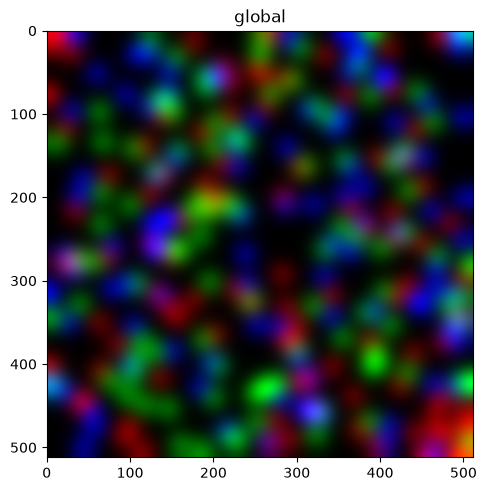

In [2]:
sdata.pl.render_images("blobs_image").pl.show()

## 2. Fixed contrast limits — `Normalize(vmin, vmax)`

Pin the window yourself. A single `Normalize` on a multi-channel image is **broadcast to every channel**.
We render one channel with a colorbar so the limits are visible.

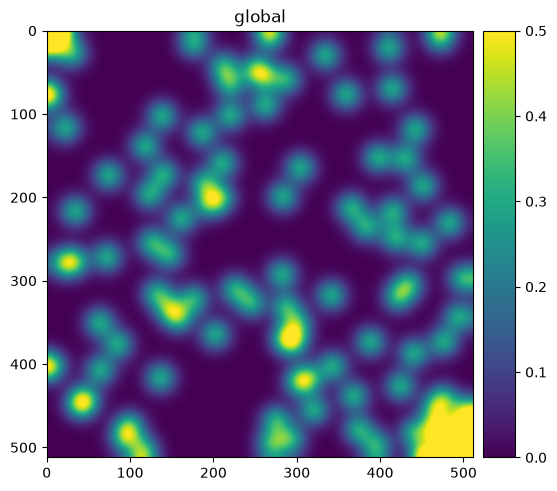

In [3]:
sdata.pl.render_images("blobs_image", channel=0, norm=Normalize(vmin=0.0, vmax=0.5), colorbar=True).pl.show()

## 3. Clipping — what happens outside `[vmin, vmax]`

With `clip=False` (the default), values below `vmin` or above `vmax` are drawn in the colormap's **under/over**
colors (the special colors a colormap shows for values past each end, set via `set_under` / `set_over`). With `clip=True`, they are clamped to the ends instead. We use a cmap with distinct under/over colors
to make the difference obvious.

First, `clip=False` — out-of-range pixels show magenta (under) and red (over):

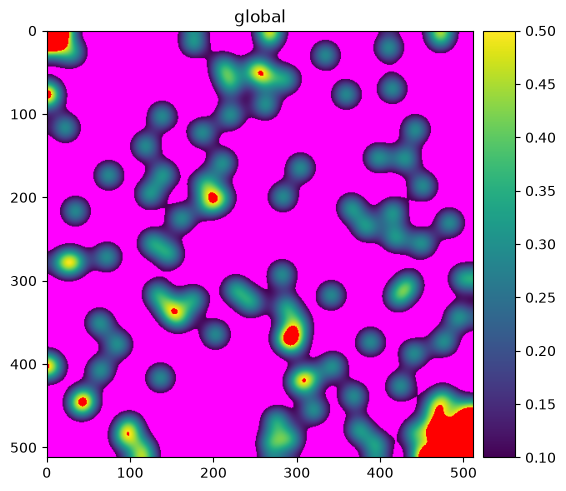

In [4]:
cmap = plt.cm.viridis.copy()
cmap.set_under("magenta")
cmap.set_over("red")

sdata.pl.render_images("blobs_image", channel=0, cmap=cmap, norm=Normalize(0.1, 0.5, clip=False)).pl.show()

Now `clip=True` — the same out-of-range pixels are clamped to the cmap ends instead:

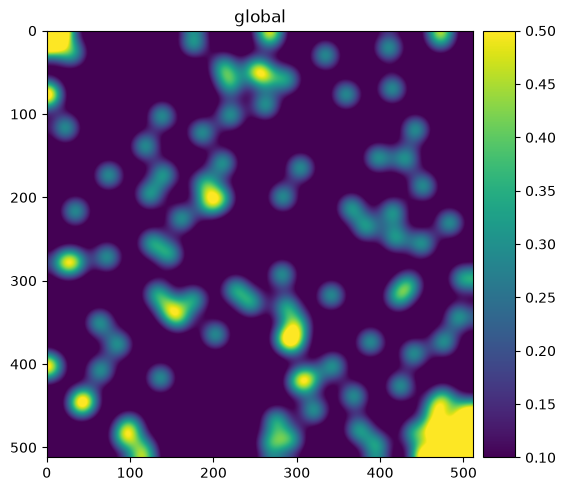

In [5]:
sdata.pl.render_images("blobs_image", channel=0, cmap=cmap, norm=Normalize(0.1, 0.5, clip=True)).pl.show()

## 4. Logarithmic scaling — `LogNorm`

For data spanning orders of magnitude. On the non-image renderers (shapes, points, labels),
`spatialdata-plot` resolves `LogNorm` limits from the **strictly-positive** data and falls back to a valid
domain when none exist, so a non-positive `vmin` never raises a late "Invalid vmin or vmax". On images,
as below, `LogNorm` is applied directly by matplotlib.

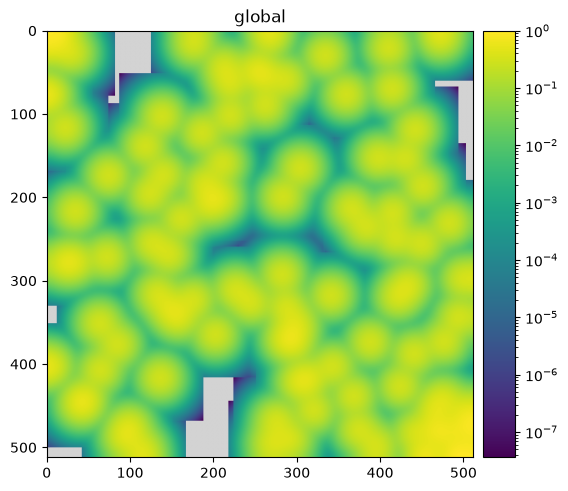

In [6]:
sdata.pl.render_images("blobs_image", channel=0, norm=LogNorm(), colorbar=True).pl.show()

## 5. Other matplotlib norms work too

Because the limits come from each norm's own logic, any `Normalize` subclass plugs in. Two common ones:
`PowerNorm` (gamma correction) and `SymLogNorm` (log scaling with a linear region around zero).

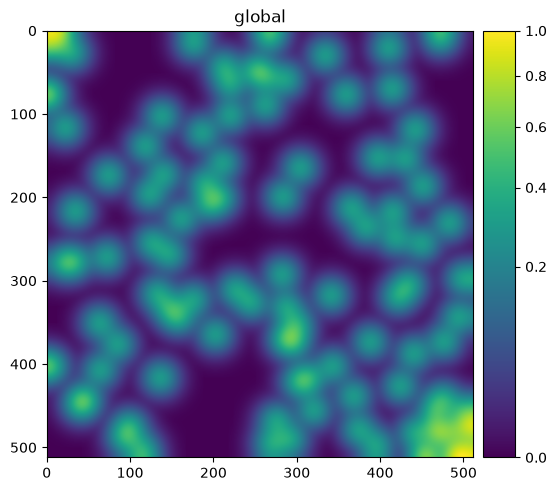

In [7]:
sdata.pl.render_images("blobs_image", channel=0, norm=PowerNorm(gamma=0.5), colorbar=True).pl.show()

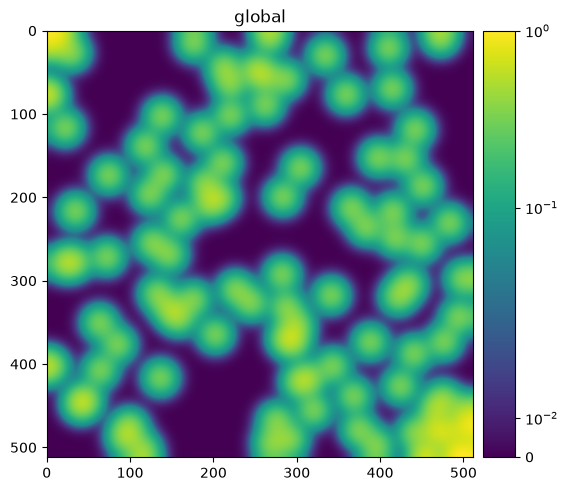

In [8]:
sdata.pl.render_images("blobs_image", channel=0, norm=SymLogNorm(linthresh=0.05), colorbar=True).pl.show()

## 6. Percentile contrast — `PercentileNormalize`

Heavy-tailed images (fluorescence, Xenium morphology) often look dim: a single bright outlier sets the min/max
`vmax` and crushes the rest of the signal to near-black. `PercentileNormalize(pmin, pmax)` derives the limits
from data **percentiles** instead — the same idea as the contrast sliders in viewers like Xenium Explorer.

- `pmin`/`pmax` are validated to satisfy `0 <= pmin < pmax <= 100`.
- NaN / inf / masked pixels are excluded from the percentile computation.
- A single instance is **autoscaled independently per channel**.

Here is the default min/max rendering of one channel:

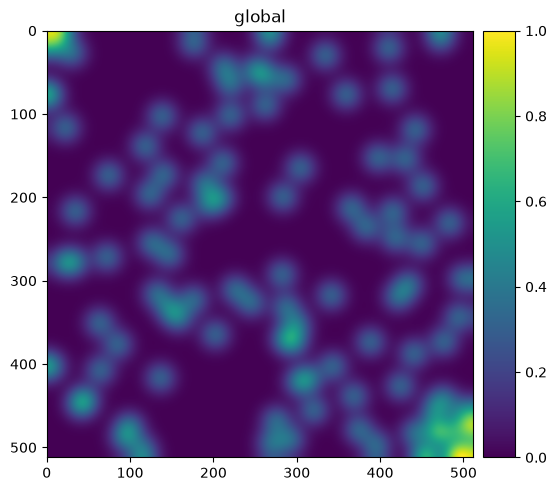

In [9]:
sdata.pl.render_images("blobs_image", channel=0).pl.show()

And the same channel with the top 10% of values clipped, lifting the bulk of the signal:

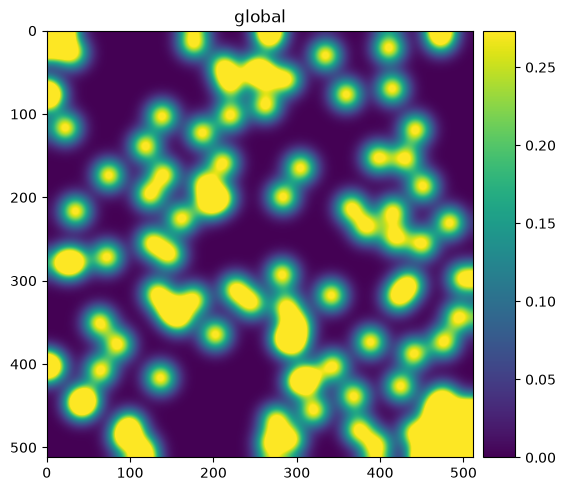

In [10]:
sdata.pl.render_images("blobs_image", channel=0, norm=PercentileNormalize(0, 90)).pl.show()

## 7. Per-channel norms for images

Pass a **list** of norms, one per channel (its length must equal the number of channels). You can mix
subclasses freely — give each channel exactly the contrast it needs.

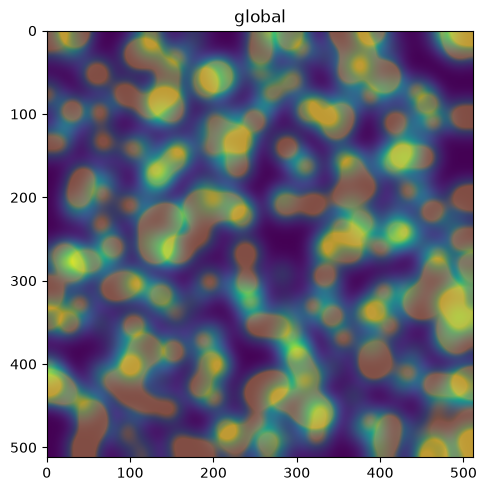

In [11]:
norms = [PercentileNormalize(0, 99), PercentileNormalize(0, 90), PercentileNormalize(0, 80)]
sdata.pl.render_images("blobs_image", channel=[0, 1, 2], norm=norms).pl.show()

WARNING  render_images: You're blending multiple cmaps. If the plot doesn't look like you expect, it might be      
         because your cmaps go from a given color to 'white', and not to 'transparent'. Therefore, the 'white' of  
         higher layers will overlay the lower layers. Consider using 'palette' instead.                            


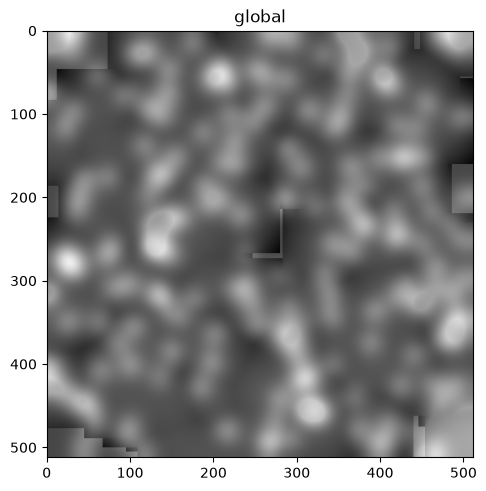

In [12]:
mixed = [Normalize(0, 0.5), LogNorm(), PercentileNormalize(2, 98)]
sdata.pl.render_images("blobs_image", channel=[0, 1, 2], norm=mixed, cmap=[plt.cm.gray] * 3).pl.show()

## 8. Combining with `transfunc`

`transfunc` transforms the **raw array first**, then `norm` scales the result. So `transfunc=np.sqrt` with a
`norm` operates on the square-rooted data — handy for pairing a fixed transform with explicit limits.

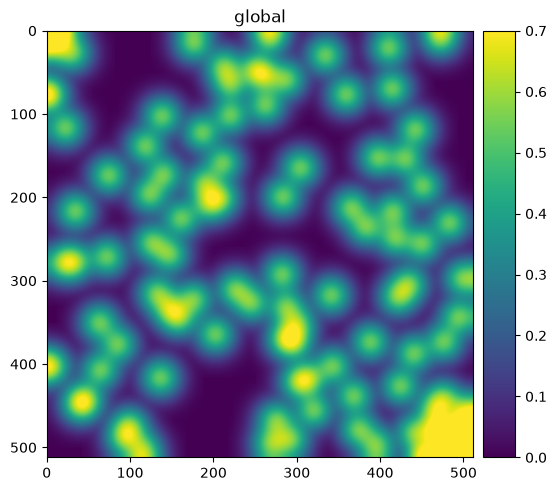

In [13]:
sdata.pl.render_images("blobs_image", channel=0, transfunc=np.sqrt, norm=Normalize(0.0, 0.7), colorbar=True).pl.show()

## 9. True RGB images

When the channels are literally named `{r, g, b(, a)}`, the RGB path composites them with one shared scale to
preserve hue balance. If you pass a `norm` with explicit `vmin`/`vmax`, it is applied per channel and clipped
to `[0, 1]`; otherwise channels are scaled by their dtype.

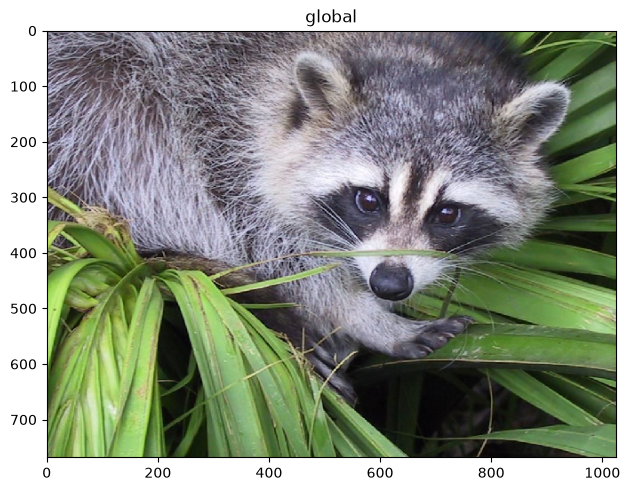

In [14]:
rac = sd.datasets.raccoon()  # a real RGB photo
rac.pl.render_images("raccoon").pl.show()

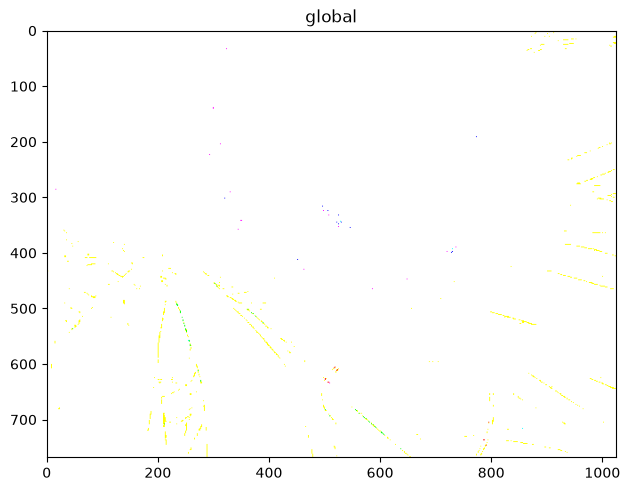

In [15]:
rac.pl.render_images("raccoon", norm=Normalize(0.0, 0.5, clip=True)).pl.show()

## 10. Norms on shapes, points, and labels

For non-image renderers, `norm` scales a continuous `color=` column. The **same resolved norm drives both the
fill colors and the colorbar**, so the bar always matches the pixels — a `LogNorm` colorbar stays logarithmic.

Shapes, colored by a continuous geometry column:

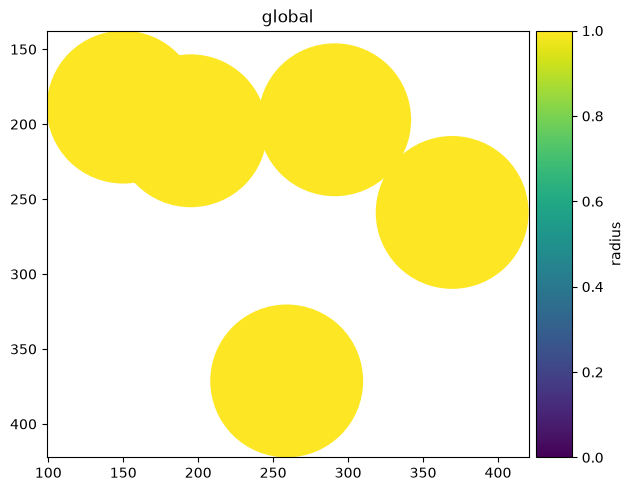

In [16]:
sdata.pl.render_shapes("blobs_circles", color="radius", norm=Normalize(), colorbar=True).pl.show()

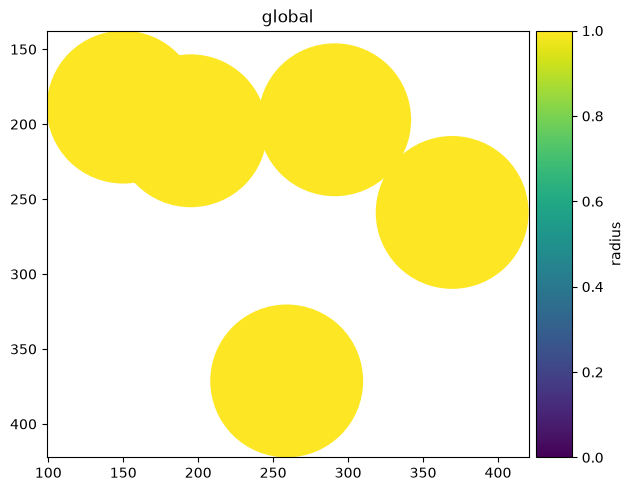

In [17]:
sdata.pl.render_shapes("blobs_circles", color="radius", norm=PercentileNormalize(5, 95), colorbar=True).pl.show()

Points, colored by a continuous column:

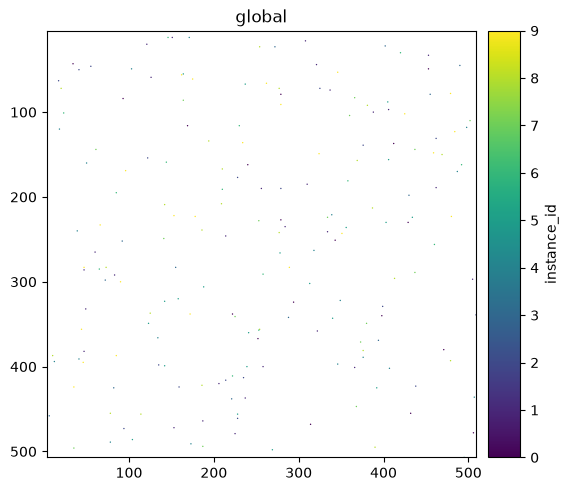

In [18]:
sdata.pl.render_points("blobs_points", color="instance_id", norm=Normalize(), colorbar=True).pl.show()

Labels, colored by a continuous table column:

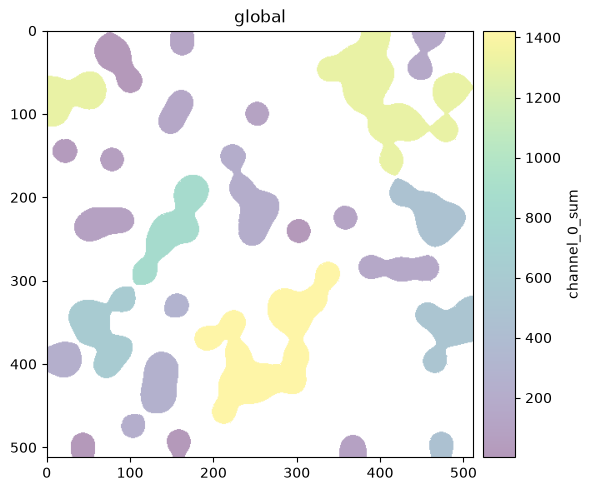

In [19]:
sdata.pl.render_labels("blobs_labels", color="channel_0_sum", norm=PercentileNormalize(2, 98), colorbar=True).pl.show()

## 11. The datashader caveat

On the **datashader** backend, contrast autoscales to the aggregated value range, **not** to a norm's
percentiles. Explicit `vmin`/`vmax` are still honored. For percentile-driven contrast on points, use the
default matplotlib backend.

The cell below passes `PercentileNormalize(5, 95)`, but on datashader those percentile limits are
ignored — the contrast follows the aggregate range instead.

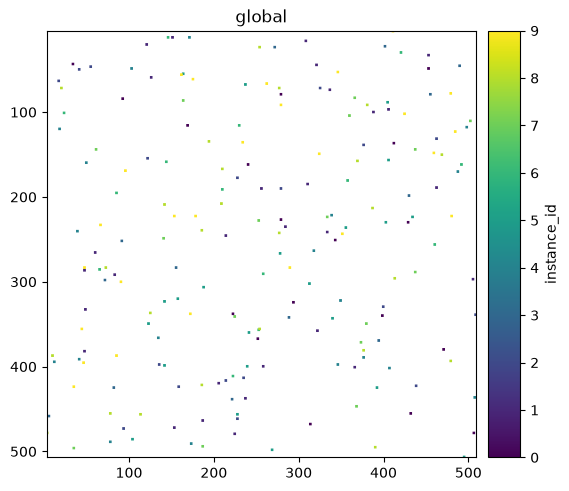

In [20]:
sdata.pl.render_points("blobs_points", color="instance_id", method="datashader", norm=PercentileNormalize(5, 95)).pl.show()

## 12. Edge cases the renderer handles for you

The renderer validates `norm` inputs up front and fails with an actionable message
rather than deep inside matplotlib.


A per-channel **norm list of the wrong length** is rejected with a clear message:

In [21]:
try:
    sdata.pl.render_images("blobs_image", channel=[0, 1, 2], norm=[Normalize(0, 1)] * 2, cmap=[plt.cm.gray] * 3).pl.show()
except ValueError as e:
    print("ValueError:", e)

ValueError: Length of 'norm' list (2) must match the number of channels (3).


And invalid percentile bounds are caught at construction time:

In [22]:
for bad in [(50, 50), (90, 10), (-1, 50), (0, 101)]:
    try:
        PercentileNormalize(*bad)
    except ValueError as e:
        print(f"PercentileNormalize{bad} -> {e}")

PercentileNormalize(50, 50) -> Require 0 <= pmin < pmax <= 100, got pmin=50, pmax=50.
PercentileNormalize(90, 10) -> Require 0 <= pmin < pmax <= 100, got pmin=90, pmax=10.
PercentileNormalize(-1, 50) -> Require 0 <= pmin < pmax <= 100, got pmin=-1, pmax=50.
PercentileNormalize(0, 101) -> Require 0 <= pmin < pmax <= 100, got pmin=0, pmax=101.


## Summary

- `norm` is a matplotlib `Normalize`; the **default is per-channel min/max** and is unchanged.
- Limits come from each norm's own logic, so `Normalize`, `LogNorm`, `PowerNorm`, `SymLogNorm`, and
  `PercentileNormalize` all just work.
- `PercentileNormalize(pmin, pmax)` fixes heavy-tailed dimness with no new parameter — it's opt-in.
- Only `render_images` accepts a **list** of norms (one per channel); single instances broadcast.
- The colorbar always reflects the resolved norm; datashader autoscales to the aggregate.